In [2]:
import pandas as pd
import plotly.express as px
import bte

In [3]:
tree = bte.MATree(pb_file="/Users/reem/2026_updated_tree.pb")

Finished 'from_pb' in 129.5435 seconds


In [4]:
all_nodes = list(tree.depth_first_expansion())
len(all_nodes)

21244182

In [5]:
all_leaves = tree.get_leaves_ids()
len(all_leaves)

17245842

In [6]:
df = pd.read_csv("/Users/reem/merged_bte_final.tsv", sep="\t")
df.head()

,node_id,parent_id,children,mutations,num_mutations,level,branch_length,subs,Counts,LLR,...,A>G_llr,CtoT_counts,C>T_llr,TtoC_counts,T>C_llr,sum_llrs,sum_contexts,country,date,num_descendants
0,Yunnan/0306-466/2020|EPI_ISL_429239|2020-03-06,node_1,[],['G15910T'],1,2,1.0,G>T,{'G>T': 1},-1.509730,...,0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,China,2020,1
1,Japan/DP0803/2020|EPI_ISL_416630|2020-02-17,node_1,[],['G4162T'],1,2,1.0,G>T,{'G>T': 1},-1.509730,...,0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,NaN,2020,1
2,node_2,node_1,['England/LEED-2A8B52/2020|EPI_ISL_539074|2020...,['T13090C'],1,2,1.0,T>C,{'T>C': 1},-0.528901,...,0.0,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020,2
3,England/LEED-2A8B52/2020|EPI_ISL_539074|2020-0...,node_2,[],"['C1191T', 'C11674T']",2,3,2.0,"C>T,C>T",{'C>T': 2},0.872360,...,0.0,"Counter({'C[C>T]A': 1, 'A[C>T]T': 1})",-0.351044,Counter(),0.000000,0.521315,-0.351044,England,2020,1
4,England/SHEF-C06CE/2020|EPI_ISL_420245|2020-03-25,node_2,[],['T15821C'],1,3,1.0,T>C,{'T>C': 1},-0.528901,...,0.0,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020,1


In [12]:
df["is_mov"] = (df["LLR"] > 3) & (df["sum_contexts"] > 2)

In [ ]:
# There is a row with a date of 1905, which is likely an error. Remove it.
bool1 = df.date.str.contains('1905').fillna(False)
df = df[~bool1]

,leaf_id,date,country,is_mov
10333765,USA/MI-MDHHS-SC45544/2024|PQ484025.1|1905-07-16,1905-07-16,USA,False


In [ ]:
df =df.drop(index=[10333765])

In [ ]:
df.to_csv("/Users/reem/df_fitness.tsv",sep="\t", index=False)

In [2]:
df = pd.read_csv("/Users/reem/df_fitness.tsv", sep="\t")

In [ ]:
df["is_mov"] = df["is_mov"].astype(int)           # is_mov is already boolean, so we can directly convert it to int

df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [ ]:
df["week"] = df["date"].dt.to_period("W-MON").dt.start_time

weekly_country = (
    df.dropna(subset=["week", "is_mov", "country"])
    .groupby(["country", "week"])
    .agg(
        mov=("is_mov", "sum"),
        total=("is_mov", "size")
    )
    .reset_index()
)

weekly_country["freq"] = weekly_country["mov"] / weekly_country["total"]
weekly_country.head()



,country,week,mov,total,freq
0,5C,2020-03-17,0,14,0.0
1,5C,2021-03-09,0,2,0.0
2,5C,2021-04-27,0,1,0.0
3,5C,2021-07-06,0,4,0.0
4,5C,2021-07-13,0,4,0.0


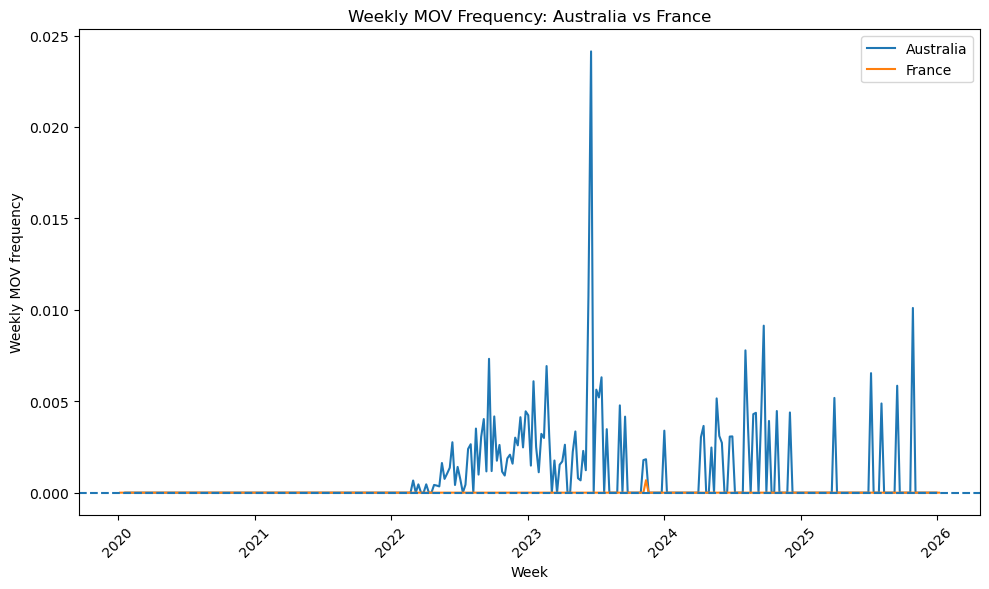

In [34]:
import matplotlib.pyplot as plt
weekly_plot = weekly_country[
    weekly_country["country"].isin(["Australia", "France"])
].copy()


plt.figure(figsize=(10,6))

for country, df_sub in weekly_plot.groupby("country"):
    plt.plot(df_sub["week"], df_sub["freq"], label=country)

plt.axhline(0, linestyle="--")
plt.ylabel("Weekly MOV frequency")
plt.xlabel("Week")
plt.legend()
plt.title("Weekly MOV Frequency: Australia vs France")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


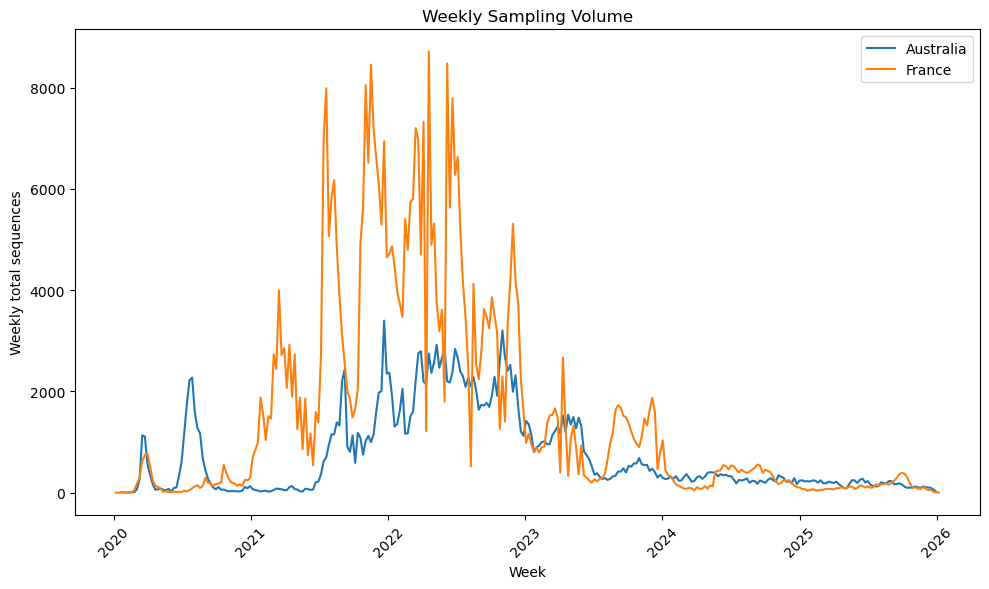

In [35]:
plt.figure(figsize=(10,6))

for country, df_sub in weekly_plot.groupby("country"):
    plt.plot(df_sub["week"], df_sub["total"], label=country)

plt.ylabel("Weekly total sequences")
plt.xlabel("Week")
plt.legend()
plt.title("Weekly Sampling Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


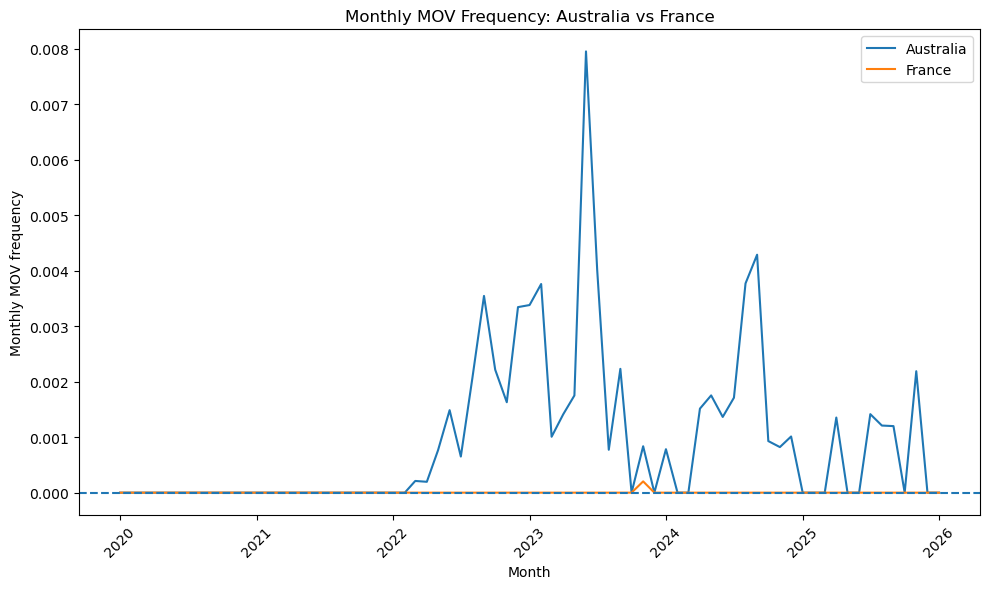

In [ ]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["month"] = df["date"].dt.to_period("M").dt.start_time

monthly = (
    df
    .groupby(["country","month"])
    .agg(
        mov=("is_mov","sum"),
        total=("is_mov","size")
    )
    .reset_index()
)

monthly["freq"] = monthly["mov"] / monthly["total"]
monthly.head()
monthly_plot = monthly[
    monthly["country"].isin(["Australia", "France"])
].copy()
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for country, df_sub in monthly_plot.groupby("country"):
    plt.plot(df_sub["month"], df_sub["freq"], label=country)

plt.axhline(0, linestyle="--")
plt.ylabel("Monthly MOV frequency")
plt.xlabel("Month")
plt.legend()
plt.title("Monthly MOV Frequency: Australia vs France")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [27]:
aus = monthly[monthly["country"] == "Australia"].copy()

first_mov_month = aus.loc[aus["mov"] > 0, "month"].min()
print(first_mov_month)

buffer_months = 2
start_month = first_mov_month - pd.DateOffset(months=buffer_months)

monthly_aus = monthly[
    (monthly["country"] == "Australia") &
    (monthly["month"] >= start_month)].copy()


2022-03-01 00:00:00


In [ ]:
# Another method

GLM models are not suitable for this kind of data that is sparse and rare with sudden blips in MOV frequency every now and then, distorting the results by showing a significant but actually meaningless result. A better idea is to compare the median/mean number of descendants between MOV nad non-MOV nodes, maybe with a statistical test like t-test or Mann-Whitney.

In [ ]:
# Do MOV nodes have more descendants than non-MOV nodes?
from scipy import stats

mov_descendants = df[(df["LLR"]>3) & (df["sum_contexts"]>2) & (df["num_mutations"] > 10)]["num_descendants"]
non_mov_descendants = df[~((df["LLR"]>3) & (df["sum_contexts"]>2))& (df["num_mutations"] > 10)]["num_descendants"]

stat, p = stats.mannwhitneyu(mov_descendants, non_mov_descendants)
print(f"Median MOV descendants: {mov_descendants.median()}")
print(f"Median non-MOV descendants: {non_mov_descendants.median()}")
print(f"Mann-Whitney p = {p:.4f}")
stat, p_mean = stats.mannwhitneyu(mov_descendants, non_mov_descendants)
print(f"Mean MOV descendants: {mov_descendants.mean()}")
print(f"Mean non-MOV descendants: {non_mov_descendants.mean()}")
print(f"Mann-Whitney mean p = {p_mean:.4f}")

Median MOV descendants: 1.0
Median non-MOV descendants: 1.0
Mann-Whitney p = 0.4967
Mean MOV descendants: 1.3220524017467248
Mean non-MOV descendants: 2.4651921821602736
Mann-Whitney mean p = 0.4967


In [ ]:
non_mov_large = df[~((df["LLR"]>3) & (df["sum_contexts"]>2)) & (df["num_mutations"] > 10)]\
    .nlargest(10, "num_descendants")[["node_id", "country", "date", "num_descendants", "num_mutations"]]
print(non_mov_large)

Iteration 1: 997 matched nodes
Iteration 2: 997 matched nodes
Iteration 3: 997 matched nodes
Iteration 4: 997 matched nodes
Iteration 5: 997 matched nodes
Iteration 6: 997 matched nodes
Iteration 7: 997 matched nodes
Iteration 8: 997 matched nodes
Iteration 9: 997 matched nodes
Iteration 10: 997 matched nodes
Iteration 11: 997 matched nodes
Iteration 12: 997 matched nodes
Iteration 13: 997 matched nodes
Iteration 14: 997 matched nodes
Iteration 15: 997 matched nodes
Iteration 16: 997 matched nodes
Iteration 17: 997 matched nodes
Iteration 18: 997 matched nodes
Iteration 19: 997 matched nodes
Iteration 20: 997 matched nodes


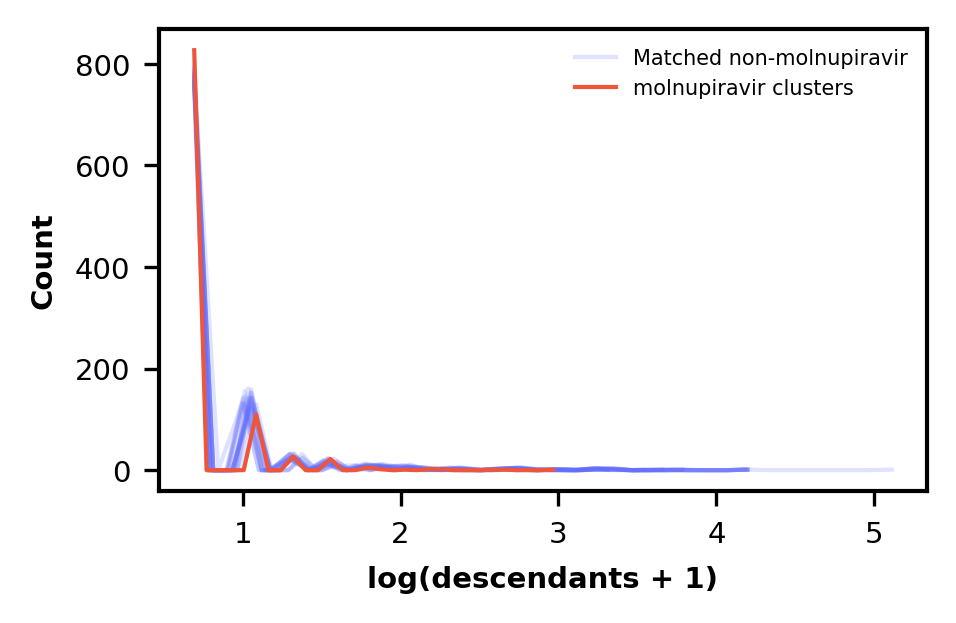

In [10]:
import random
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.labelcolor'] = 'black'
mpl.rcParams['xtick.color'] = 'black'
mpl.rcParams['ytick.color'] = 'black'
mpl.rcParams['axes.linewidth'] = 1
mpl.rcParams['xtick.labelsize'] = 7
mpl.rcParams['ytick.labelsize'] = 7
mpl.rcParams['axes.labelsize'] = 7

width_in = 3.3
height_in = 2
dpi=300

fig, ax = plt.subplots(figsize=(width_in, height_in), dpi=dpi)
fig.patch.set_facecolor('white')

# MOV nodes
mov_nodes = df[(df["LLR"] > 3) & (df["sum_contexts"] > 2)].copy()

# non-MOV nodes
non_mov_nodes = df[~(df["LLR"] > 3) & (df["sum_contexts"] > 2)].copy()

# Matching function - for each MOV node find a non-MOV node 
# with same country AND year
def match_once(mov_nodes, non_mov_nodes):
    matched = []
    for _, mov_row in mov_nodes.iterrows():
        # Find non-MOV nodes with same country and year
        pool = non_mov_nodes[
            (non_mov_nodes["country"] == mov_row["country"]) &
            (non_mov_nodes["date"] == mov_row["date"])
        ]
        if len(pool) > 0:
            matched.append(pool.sample(1).iloc[0]["num_descendants"])
    return matched

# Run 20 iterations
all_matched = []
for i in range(20):
    matched = match_once(mov_nodes, non_mov_nodes)
    all_matched.append(matched)
    print(f"Iteration {i+1}: {len(matched)} matched nodes")

# Plot 20 matched distributions as faint lines
# show legend only for the first line to avoid clutter
for i, matched in enumerate(all_matched):
    counts, bins = np.histogram(np.log1p(matched), bins=30)
    ax.plot(bins[:-1], counts, alpha=0.2, color="#636EFA", linewidth=1, label="Matched non-molnupiravir" if i == 0 else "_nolegend_")

# Plot MOV distribution
mov_counts, mov_bins = np.histogram(
    np.log1p(mov_nodes["num_descendants"]), bins=30)
ax.plot(mov_bins[:-1], mov_counts, color="#EF553B", 
        linewidth=1, label="molnupiravir clusters")


ax.set_xlabel("log(descendants + 1)", fontweight="bold")
ax.set_ylabel("Count", fontweight="bold")
ax.legend(fontsize=5, frameon=False)
plt.savefig("/Users/reem/molnupiravir_paper/Figures/fitness_plot.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
plt.savefig("fitness.png", dpi=300, bbox_inches="tight")

In [4]:
from scipy.stats import mannwhitneyu
import numpy as np

mov_desc = mov_nodes["num_descendants"].values
effect_sizes = []
p_values = []
all_matched = []

for i in range(20):
    matched = match_once(mov_nodes, non_mov_nodes)
    all_matched.append(matched)
    
    matched_arr = np.array(matched)
    stat, p = mannwhitneyu(mov_desc, matched_arr, alternative="two-sided")
    r = 1 - (2 * stat) / (len(mov_desc) * len(matched_arr))
    effect_sizes.append(abs(r))
    p_values.append(p)
    
    print(f"Iteration {i+1}: n_matched={len(matched)}, r={abs(r):.3f}, p={p:.3e}")

print(f"\nMedian effect size (r): {np.median(effect_sizes):.3f}")
print(f"SD: {np.std(effect_sizes):.3f}")
print(f"Range: {min(effect_sizes):.3f} - {max(effect_sizes):.3f}")

Iteration 1: n_matched=997, r=0.056, p=1.797e-03
Iteration 2: n_matched=997, r=0.052, p=3.793e-03
Iteration 3: n_matched=997, r=0.044, p=1.469e-02
Iteration 4: n_matched=997, r=0.036, p=4.248e-02
Iteration 5: n_matched=997, r=0.056, p=1.738e-03
Iteration 6: n_matched=997, r=0.030, p=8.393e-02
Iteration 7: n_matched=997, r=0.050, p=5.665e-03
Iteration 8: n_matched=997, r=0.068, p=1.854e-04
Iteration 9: n_matched=997, r=0.048, p=7.563e-03
Iteration 10: n_matched=997, r=0.047, p=8.288e-03
Iteration 11: n_matched=997, r=0.056, p=1.768e-03
Iteration 12: n_matched=997, r=0.037, p=3.538e-02
Iteration 13: n_matched=997, r=0.044, p=1.417e-02
Iteration 14: n_matched=997, r=0.032, p=7.013e-02
Iteration 15: n_matched=997, r=0.035, p=5.025e-02
Iteration 16: n_matched=997, r=0.037, p=3.575e-02
Iteration 17: n_matched=997, r=0.035, p=4.612e-02
Iteration 18: n_matched=997, r=0.066, p=2.842e-04
Iteration 19: n_matched=997, r=0.063, p=5.565e-04
Iteration 20: n_matched=997, r=0.042, p=1.758e-02

Median e

In [8]:
# MOV IQR
print(f"MOV median: {np.median(mov_desc):.1f}")
print(f"MOV IQR: {np.percentile(mov_desc, 25):.1f} - {np.percentile(mov_desc, 75):.1f}")
print(f"MOV mean: {np.mean(mov_desc):.2f}")

# Non-MOV IQR (average across all 20 iterations)
all_matched_flat = [np.median(m) for m in all_matched]
print(f"\nNon-MOV median across iterations: {np.median(all_matched_flat):.1f}")

# Per iteration IQR
for i, matched in enumerate(all_matched[:20]):  # check first 3
    arr = np.array(matched)
    print(f"Iteration {i+1} IQR: {np.percentile(arr,25):.1f} - {np.percentile(arr,75):.1f}")

MOV median: 1.0
MOV IQR: 1.0 - 1.0
MOV mean: 1.34

Non-MOV median across iterations: 1.0
Iteration 1 IQR: 1.0 - 1.0
Iteration 2 IQR: 1.0 - 1.0
Iteration 3 IQR: 1.0 - 1.0
Iteration 4 IQR: 1.0 - 1.0
Iteration 5 IQR: 1.0 - 1.0
Iteration 6 IQR: 1.0 - 1.0
Iteration 7 IQR: 1.0 - 1.0
Iteration 8 IQR: 1.0 - 1.0
Iteration 9 IQR: 1.0 - 1.0
Iteration 10 IQR: 1.0 - 1.0
Iteration 11 IQR: 1.0 - 1.0
Iteration 12 IQR: 1.0 - 1.0
Iteration 13 IQR: 1.0 - 1.0
Iteration 14 IQR: 1.0 - 1.0
Iteration 15 IQR: 1.0 - 1.0
Iteration 16 IQR: 1.0 - 1.0
Iteration 17 IQR: 1.0 - 1.0
Iteration 18 IQR: 1.0 - 1.0
Iteration 19 IQR: 1.0 - 1.0
Iteration 20 IQR: 1.0 - 1.0


In [14]:
# Look at percentiles beyond IQR
for label, data in [("MOV", mov_desc), ("Non-MOV iter 1", np.array(all_matched[0]))]:
    print(f"\n{label}:")
    print(f"  Median: {np.median(data):.1f}")
    print(f"  Mean: {np.mean(data):.2f}")
    print(f"  75th percentile: {np.percentile(data, 75):.1f}")
    print(f"  90th percentile: {np.percentile(data, 90):.1f}")
    print(f"  95th percentile: {np.percentile(data, 95):.1f}")
    print(f"  Max: {np.max(data):.1f}")
   
    


MOV:
  Median: 1.0
  Mean: 1.34
  75th percentile: 1.0
  90th percentile: 2.0
  95th percentile: 3.0
  Max: 20.0

Non-MOV iter 1:
  Median: 1.0
  Mean: 1.68
  75th percentile: 1.0
  90th percentile: 2.0
  95th percentile: 4.0
  Max: 123.0


In [21]:
# Get mean and median of the 99th percentile across iterations for MOV and non-MOV
print(f"MOV 99th percentile: {np.percentile(mov_nodes['num_descendants'], 99):.1f}")

max_vals = [np.max(np.array(m)) for m in all_matched]
print(f"Non_MOV mean 99th percentile: {np.mean([np.percentile(m, 99) for m in all_matched]):.1f} (range {min([np.percentile(m, 99) for m in all_matched]):.1f}-{max([np.percentile(m, 99) for m in all_matched]):.1f})")
print(f"Non_MOV median 99th percentile: {np.median([np.percentile(m, 99) for m in all_matched]):.1f} (range {min(max_vals):.1f}-{max(max_vals):.1f})")

MOV 99th percentile: 5.0
Non_MOV mean 99th percentile: 13.5 (range 7.0-22.1)
Non_MOV median 99th percentile: 14.0 (range 25.0-139.0)


In [8]:
from scipy import stats

all_matched_flat = [x for iteration in all_matched for x in iteration]
mov_descendants = mov_nodes["num_descendants"].values

# Run the test
stat, p = stats.mannwhitneyu(
    mov_descendants,
    all_matched_flat,
    alternative="less"  # one-tailed: MOV has FEWER descendants
)

# Effect size
r = 1 - (2 * stat) / (len(mov_descendants) * len(all_matched_flat))

print(f"Median MOV descendants:     {np.median(mov_descendants):.1f}")
print(f"Median non-MOV descendants: {np.median(all_matched_flat):.1f}")
print(f"Mann-Whitney U: {stat:.0f},  p = {p:.2e},  effect size r = {r:.3f}")


Median MOV descendants:     1.0
Median non-MOV descendants: 1.0
Mann-Whitney U: 9545558,  p = 5.67e-04,  effect size r = 0.044
